# Antialiasing

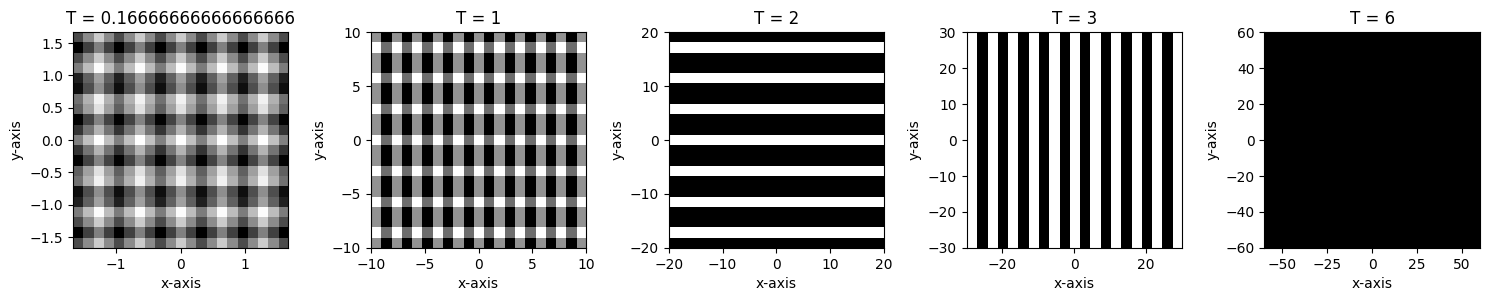

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    """Function f(x) = cos(3πx) + cos(10/3 πy)"""
    return np.cos(3 * np.pi * x) + np.cos((10/3) * np.pi*y)

# Define values of T
T_values = [1/6, 1, 2, 3, 6]

# Define grid limits
grid_size = 10  # Number of integer steps in each direction

fig, axes = plt.subplots(1, len(T_values), figsize=(15, 3))

for i, T in enumerate(T_values):
    # Generate sampling points
    k1, k2 = np.meshgrid(np.arange(-grid_size, grid_size+1), np.arange(-grid_size, grid_size+1))
    x, y = k1 * T, k2 * T  # Sampling at x = kT
    
    # Compute function values
    z = f(x, y)
    
    # Plot as an image
    ax = axes[i]
    ax.imshow(z, cmap='gray', extent=[-grid_size*T, grid_size*T, -grid_size*T, grid_size*T])
    ax.set_title(f"T = {T}")
    ax.set_xlabel("x-axis")
    ax.set_ylabel("y-axis")

plt.tight_layout()
plt.show()


## (a) Matching the images

<br>
T=1/6 -> ii
<br>
    T=1 -> iv
<br>
    T=2 -> iii
<br>
    T=3 -> v
<br>
    T=6 -> i
<br>

## (b) To determine the Fourier Transforms of:

g(x)=cos⁡(3 πx)
<br>
h(x)=cos⁡(10/3 πx)

we use the Fourier transform property:
<br>
F[cos⁡(2πf_0x)]=1/2[δ(f−f_0)+δ(f+f_0)]

Applying this:

    g(x)=cos⁡(3 πx)g(x) has frequencies ±3/2.
<br>
    h(x)=cos⁡(10/3 πx)h(x) has frequencies ±5/3.

Thus:
<br>
F[g(x)]=1/2[δ(f−3/2)+δ(f+3/2)]
<br>
F[h(x)]=1/2[δ(f−5/3)+δ(f+5/3)]

Now, we will numerically compute and plot these Fourier transforms in the range f∈[−4π,4π].

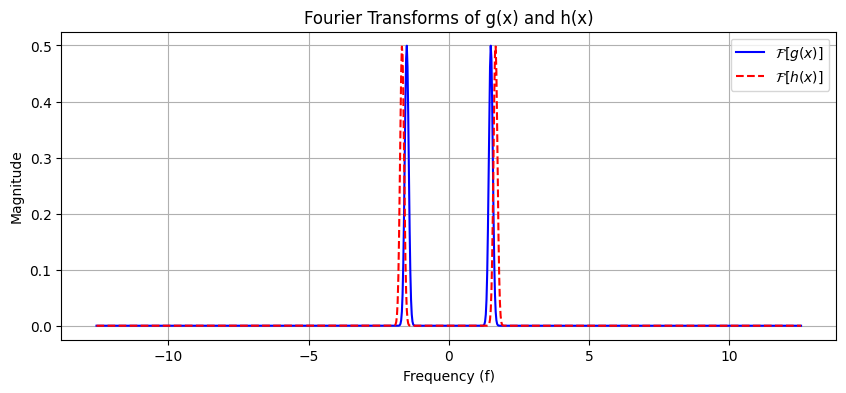

In [5]:
from scipy.fft import fftshift, fft
# from scipy.signal import gaussian

# Define frequency range
f_range = np.linspace(-4*np.pi, 4*np.pi, 1000)

# Define Gaussian window to approximate delta functions
delta_width = 0.1  # Controls how sharp the peak is

# Compute Fourier Transforms as Gaussian approximations of delta functions
G_f = 0.5 * (np.exp(-((f_range - 3/2) / delta_width)**2) + np.exp(-((f_range + 3/2) / delta_width)**2))
H_f = 0.5 * (np.exp(-((f_range - 5/3) / delta_width)**2) + np.exp(-((f_range + 5/3) / delta_width)**2))

# Plot results
plt.figure(figsize=(10, 4))
plt.plot(f_range, G_f, label=r'$\mathcal{F}[g(x)]$', color='b')
plt.plot(f_range, H_f, label=r'$\mathcal{F}[h(x)]$', color='r', linestyle='--')

plt.xlabel("Frequency (f)")
plt.ylabel("Magnitude")
plt.title("Fourier Transforms of g(x) and h(x)")
plt.legend()
plt.grid()

plt.show()


## (c) 
Using the Fourier transform property:
<br>
F[f(x)⋅∑δ(x−k)]=∑F[f](f − n)

Thus, the Fourier transforms of g1(x)g1​(x) and h1(x)h1​(x) will be periodic replications of F[g] and F[h] at integer shifts.

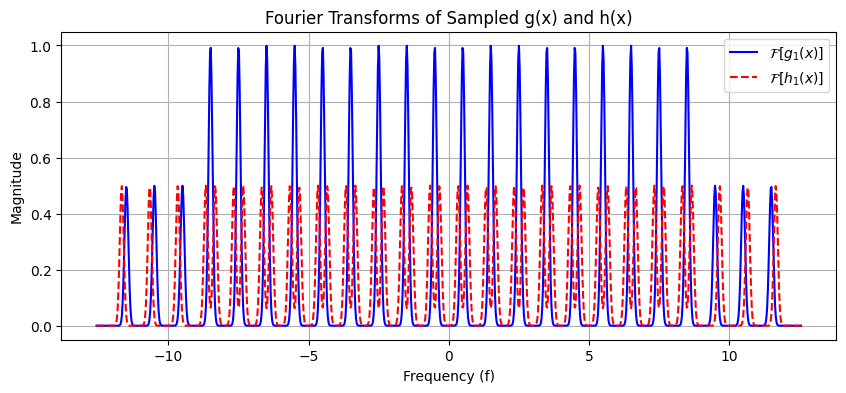

In [6]:
# Define frequency range
f_range = np.linspace(-4*np.pi, 4*np.pi, 1000)

# Define periodic replications of G_f and H_f at integer shifts
G1_f = np.zeros_like(f_range)
H1_f = np.zeros_like(f_range)

for n in range(-10, 11):  # Sum over multiple integer shifts
    G1_f += 0.5 * (np.exp(-((f_range - (3/2 + n)) / delta_width)**2) + np.exp(-((f_range + (3/2 + n)) / delta_width)**2))
    H1_f += 0.5 * (np.exp(-((f_range - (5/3 + n)) / delta_width)**2) + np.exp(-((f_range + (5/3 + n)) / delta_width)**2))

# Plot the results
plt.figure(figsize=(10, 4))
plt.plot(f_range, G1_f, label=r'$\mathcal{F}[g_1(x)]$', color='b')
plt.plot(f_range, H1_f, label=r'$\mathcal{F}[h_1(x)]$', color='r', linestyle='--')

plt.xlabel("Frequency (f)")
plt.ylabel("Magnitude")
plt.title("Fourier Transforms of Sampled g(x) and h(x)")
plt.legend()
plt.grid()

plt.show()


## (d)
The Nyquist frequency is 1/2​.
<br>
The frequencies in g(x) are at ±3/2, which exceed the Nyquist limit 1/2, meaning g(x) cannot be reconstructed exactly from its samples.
<br>
The frequencies in h(x) are at ±5/3​, which also exceed the Nyquist limit 1/2, meaning h(x) cannot be reconstructed exactly either.

## (e)

Both g(x) and h(x) can be perfectly reconstructed if and only if:

fs​≥2fmax​ (fmax =5/3) (fs=1/T)

T≤3/10

Thus, the valid range of TT is:
<br>
0<T≤3/10

If T>3/10​, aliasing occurs, and perfect reconstruction is no longer possible.

# Acquisition System

## (a) Block Diagram of the System

The process involves three main stages:<br>

Blurring by the Camera: The original image f(x,y) is convolved with the blur filter h_blr(x,y).<br>
Sampling: The blurred image is sampled using an ideal impulse train.<br>
LCD Display: The sampled image is filtered by the LCD response h_LCD(x,y).<br>

Block diagram:<br>

f(x,y)  <br>--->  (Blur: h_blr(x,y))  --->  f_blurred(x,y)  <br>
       --->  (Sampling: p(x,y))  --->  f_sampled(x,y) <br>
       --->  (LCD Filtering: h_LCD(x,y))  --->  g(x,y) <br>

### (b) Express g(x,y) in terms of f(x,y)
Blurring Stage:

The camera applies a 2D convolution with h_blr(x,y):

f_blurred(x,y) = f(x,y) * h_blr(x,y)

where h_blr(x,y) = sinc(x) sinc(y).
Sampling Stage:

The blurred image is sampled using an ideal impulse train:

f_sampled(x,y) = f_blurred(x,y) * p(x,y)

where p(x,y) = sum_k delta(x-k, y-k) for all k in Z^2.
LCD Display Filtering:

The sampled image is convolved with the LCD impulse response:

g(x,y) = f_sampled(x,y) * h_LCD(x,y)

where h_LCD(x,y) = rect(x/pi) rect(y/pi).
Final Expression:

g(x,y) = ( ( f(x,y) * h_blr(x,y) ) * p(x,y) ) * h_LCD(x,y)

### (c) Express g_hat(u,v) in terms of f_hat(u,v)

Taking the Fourier transform of both sides:
Blurring Stage (Convolution Theorem):

f_hat_blurred(u,v) = f_hat(u,v) * h_hat_blr(u,v)

The Fourier transform of h_blr(x,y) = sinc(x) sinc(y) is:

h_hat_blr(u,v) = rect(u/pi) rect(v/pi)

So,

f_hat_blurred(u,v) = f_hat(u,v) * rect(u/pi) rect(v/pi)
Sampling Stage (Fourier Series Expansion):

Sampling by an impulse train results in periodic replication in the Fourier domain:

f_hat_sampled(u,v) = sum_k f_hat_blurred(u - 2pik, v - 2pik)
LCD Filtering Stage (Multiplication in Fourier Domain):

The Fourier transform of h_LCD(x,y) = rect(x) rect(y) is:

h_hat_LCD(u,v) = sinc(piu) sinc(piv)

Applying the convolution theorem:

g_hat(u,v) = ( sum_k f_hat(u - 2pik, v - 2pik) * rect((u - 2pik)/pi) rect((v - 2pik)/pi) ) * sinc(piu) sinc(piv)

This is the final expression for g_hat(u,v).


# Lloyd-Max 

We need to prove that the expected value of the original graylevel F is equal to the expected value of the quantized version F̃ = Q(F), i.e.,<br>

E[F] = E[F̃]<br>

where F ~ p(f) is the probability density function (p.d.f.) of the graylevel values.<br>

## Step 1: Expected Value Definitions

The expectation of F is given by:<br>

E[F] = ∫ f p(f) df<br>

The expectation of F̃ is:<br>

E[F̃] = ∫ Q(f) p(f) df<br>

where Q(f) is the Lloyd-Max quantization function.<br>

## Step 2: Lloyd-Max Quantization Structure

A Lloyd-Max quantizer partitions the real line into intervals {(s_i, s_{i+1})}, where each interval (s_i, s_{i+1}) is mapped to a quantization level y_i. That is,<br>

Q(f) =<br>
&nbsp;&nbsp;&nbsp;&nbsp;y_1,  if  s_1 ≤ f < s_2<br>
&nbsp;&nbsp;&nbsp;&nbsp;y_2,  if  s_2 ≤ f < s_3<br>
&nbsp;&nbsp;&nbsp;&nbsp;...<br>
&nbsp;&nbsp;&nbsp;&nbsp;y_N,  if  s_N ≤ f < s_{N+1}<br>

So, the expectation of F̃ can be rewritten as a sum over all quantization levels:<br>

E[F̃] = ∑ y_i ∫_{s_i}^{s_{i+1}} p(f) df<br>

where each term represents the probability mass of the input values falling into interval (s_i, s_{i+1}), scaled by the corresponding quantization level y_i.<br>

## Step 3: Lloyd-Max Optimality Condition

The Lloyd-Max quantizer minimizes the quantization error by ensuring that the quantization levels y_i are chosen as the centroids of their respective intervals, i.e.,<br>

y_i = (∫_{s_i}^{s_{i+1}} f p(f) df) / (∫_{s_i}^{s_{i+1}} p(f) df)<br>

which means that each quantization level is the conditional expectation of f within its quantization interval.<br>

## Step 4: Compute E[F̃] Using Centroids

Substituting y_i into the expectation formula:<br>

E[F̃] = ∑ ( (∫_{s_i}^{s_{i+1}} f p(f) df) / (∫_{s_i}^{s_{i+1}} p(f) df) ) * ∫_{s_i}^{s_{i+1}} p(f) df<br>

Since the denominator cancels with the probability mass term, this simplifies to:<br>

E[F̃] = ∑ ∫_{s_i}^{s_{i+1}} f p(f) df<br>

Since these are disjoint partitions covering the entire range of f, we can rewrite this as:<br>

E[F̃] = ∫ f p(f) df = E[F]<br>

Thus, we have proven that:<br>

E[F] = E[F̃]<br>

which shows that Lloyd-Max quantization does not change the mean of the image intensities, meaning it is unbiased.<br>


# Difference Equations

## (a) Solve the 1D Difference Equation using the Z-Transform

The given recursive equation is:<br>

f[k] = δ[k] + a f[k-1]<br>

### Step 1: Take the Z-Transform

Taking the Z-transform on both sides:<br>

F(z) = Z{f[k]} = Z{δ[k]} + a Z{f[k-1]}<br>

Using the known Z-transform properties:<br>

Z{δ[k]} = 1<br>
Z{f[k-1]} = z⁻¹ F(z)<br>

Substituting these:<br>

F(z) = 1 + a z⁻¹ F(z)<br>

### Step 2: Solve for F(z)

Rearrange the equation:<br>

F(z) - a z⁻¹ F(z) = 1<br>
F(z) (1 - a z⁻¹) = 1<br>
F(z) = 1 / (1 - a z⁻¹)<br>

### Step 3: Compute f[k] Using Inverse Z-Transform

Using the standard Z-transform pair:<br>

Z⁻¹{1 / (1 - a z⁻¹)} = a^k u[k]<br>

Thus, the explicit solution is:<br>

f[k] = a^k u[k]<br>

---

## (b) Compute the 2D Z-Transform

The given function is:<br>

f[k] = u[k₁ + 3] u[4 - k₂] e^(2k₂ - k₁)<br>

### Step 1: Take the 2D Z-Transform

Using the definition of the 2D Z-transform:<br>

F(z₁, z₂) = ∑∑ f[k₁, k₂] z₁⁻ᵏ¹ z₂⁻ᵏ²<br>

Substituting f[k]:<br>

F(z₁, z₂) = ∑∑ u[k₁ + 3] u[4 - k₂] e^(2k₂ - k₁) z₁⁻ᵏ¹ z₂⁻ᵏ²<br>

Since u[k₁ + 3] is 1 for k₁ ≥ -3 and u[4 - k₂] is 1 for k₂ ≤ 4, we sum over these ranges:<br>

F(z₁, z₂) = ∑ (k₁ = -3 to ∞) ∑ (k₂ = -∞ to 4) e^(2k₂ - k₁) z₁⁻ᵏ¹ z₂⁻ᵏ²<br>

Splitting the exponent:<br>

F(z₁, z₂) = ∑ (k₁ = -3 to ∞) e^(-k₁) z₁⁻ᵏ¹ ∑ (k₂ = -∞ to 4) e^(2k₂) z₂⁻ᵏ²<br>

Recognizing the geometric series:<br>

∑ e^(-k₁) z₁⁻ᵏ¹ = z₁³ / (1 - e⁻¹ z₁⁻¹),  for |e⁻¹ z₁⁻¹| < 1<br>
∑ e^(2k₂) z₂⁻ᵏ² = (1 - e⁴ z₂⁻⁴) / (1 - e² z₂⁻¹),  for |e² z₂⁻¹| < 1<br>

Thus, the final Z-transform is:<br>

F(z₁, z₂) = (z₁³ / (1 - e⁻¹ z₁⁻¹)) * ((1 - e⁴ z₂⁻⁴) / (1 - e² z₂⁻¹))<br>

---

## (c) Solve the 2D Difference Equation using the Z-Transform

The given 2D difference equation is:<br>

f[k₁, k₂] = δ[k₁, k₂] + a f[k₁ - 1, k₂] + b f[k₁, k₂ - 1] - ab f[k₁ - 1, k₂ - 1]<br>

### Step 1: Take the 2D Z-Transform

Taking the Z-transform of both sides:<br>

F(z₁, z₂) = Z{δ[k₁, k₂]} + a Z{f[k₁ - 1, k₂]} + b Z{f[k₁, k₂ - 1]} - ab Z{f[k₁ - 1, k₂ - 1]}<br>

Using the standard properties:<br>

Z{δ[k₁, k₂]} = 1<br>
Z{f[k₁ - 1, k₂]} = z₁⁻¹ F(z₁, z₂)<br>
Z{f[k₁, k₂ - 1]} = z₂⁻¹ F(z₁, z₂)<br>
Z{f[k₁ - 1, k₂ - 1]} = z₁⁻¹ z₂⁻¹ F(z₁, z₂)<br>

Substituting these:<br>

F(z₁, z₂) = 1 + a z₁⁻¹ F(z₁, z₂) + b z₂⁻¹ F(z₁, z₂) - ab z₁⁻¹ z₂⁻¹ F(z₁, z₂)<br>

### Step 2: Solve for F(z₁, z₂)

Rearrange:<br>

F(z₁, z₂) (1 - a z₁⁻¹ - b z₂⁻¹ + ab z₁⁻¹ z₂⁻¹) = 1<br>

Solving for F(z₁, z₂):<br>

F(z₁, z₂) = 1 / (1 - a z₁⁻¹ - b z₂⁻¹ + ab z₁⁻¹ z₂⁻¹)<br>

### Step 3: Compute f[k₁, k₂] Using Inverse Z-Transform

Using the standard result:<br>

Z⁻¹{ 1 / (1 - a z₁⁻¹ - b z₂⁻¹ + ab z₁⁻¹ z₂⁻¹) } = a^k₁ b^k₂ u[k₁] u[k₂]<br>

Thus, the explicit solution is:<br>

f[k₁, k₂] = a^k₁ b^k₂ u[k₁] u[k₂]<br>


# Discrete Filtering

## (a) Compute the Z-Transform and Magnitude Response

The given filter mask is:<br>  
w₁ = (1/4) * [-1   2] - 1  

Expanding:<br>  
w₁ = [-1/4   1/2] - 1 = [-5/4   1/2]  

Thus, the impulse response is:<br>  
h₁[k] = (-5/4) δ[k] + (1/2) δ[k-1]  

### Step 1: Compute the Z-Transform

Taking the Z-transform:<br>  
H₁(z) = (-5/4) + (1/2) z⁻¹  

### Step 2: Compute Frequency Response

The frequency response is obtained by substituting z = e^{jω}:<br>  
H₁(e^{jω}) = (-5/4) + (1/2)e^{-jω}  

### Step 3: Plot Magnitude Response

The magnitude response is:<br>  
|H₁(e^{jω})| = |(-5/4) + (1/2)e^{-jω}|  

(Plot this function over ω ∈ [-π, π].)  

### Step 4: Filter Type

- The filter attenuates low frequencies and has a zero at DC (ω=0), meaning it removes low frequencies.<br>  
- This suggests that the filter behaves as a high-pass (HP) filter.  

**Answer:** HP (High-Pass) Filter  

## (b) Compute the 2D Z-Transform

The given 2D impulse response is:<br>  
h[k₁, k₂] = h₁[k₁] h₁[k₂]  

Expanding:<br>  
h[k₁, k₂] = (-5/4) δ[k₁] + (1/2) δ[k₁-1] * (-5/4) δ[k₂] + (1/2) δ[k₂-1]  

which expands to:<br>  
h[k₁, k₂] = (-5/4)(-5/4) δ[k₁, k₂] + (-5/4)(1/2) δ[k₁, k₂-1] + (1/2)(-5/4) δ[k₁-1, k₂] + (1/2)(1/2) δ[k₁-1, k₂-1]  

### Step 1: Compute 2D Z-Transform

Taking the Z-transform:<br>  
H(z₁, z₂) = (-5/4)(-5/4) + (-5/4)(1/2) z₂⁻¹ + (1/2)(-5/4) z₁⁻¹ + (1/2)(1/2) z₁⁻¹ z₂⁻¹  

which simplifies to:<br>  
H(z₁, z₂) = 25/16 - (5/8) z₂⁻¹ - (5/8) z₁⁻¹ + (1/4) z₁⁻¹ z₂⁻¹  

### Step 2: Filter Type

- This is a high-pass filter in both dimensions, meaning it removes low frequencies along both axes.  

**Answer:** HP (High-Pass) Filter in 2D  

## (c) Find the Filter Mask and Type

The given frequency response is:<br>  
H(e^{jω}) = (cos(ω/2))²  

### Step 1: Identify the Filter Type

- At ω = 0: H(0) = (cos(0))² = 1  
- At ω = π: H(π) = (cos(π/2))² = 0  

Since it allows low frequencies to pass and attenuates high frequencies, this is a low-pass (LP) filter.  

### Step 2: Compute the Mask

From H(e^{jω}) = (cos(ω/2))², we recognize that:<br>  
w = [1/4   1/2   1/4]  

where the center (boxed) value is the filter origin.  

**Answer:** LP (Low-Pass) Filter with Mask [1/4 1/2 1/4]  

## (d) Compute the Z-Transform and Compare to (a)

The given impulse response is:<br>  
h[k] = (1/4) * [-1   0   2] - 1  

Expanding:<br>  
h[k] = [-1/4   0   1/2] - 1 = [-5/4   0   1/2]  

Thus:<br>  
h[k] = (-5/4) δ[k] + (1/2) δ[k-2]  

### Step 1: Compute Z-Transform

Taking the Z-transform:<br>  
H(z) = (-5/4) + (1/2) z⁻²  

### Step 2: Compute Frequency Response

Using z = e^{jω}:<br>  
H(e^{jω}) = (-5/4) + (1/2)e^{-j2ω}  

### Step 3: Plot and Identify Filter Type

- Compared to (a), this filter introduces a delay by 2 samples.<br>  
- It still attenuates low frequencies, but with a different phase response.  

Since it primarily removes low frequencies, it is still high-pass (HP).  

**Answer:** HP (High-Pass) Filter  

## Final Answers

- **(a)** HP (High-Pass) Filter  
- **(b)** HP (High-Pass) Filter in 2D  
- **(c)** LP (Low-Pass) Filter with Mask [1/4 1/2 1/4]  
- **(d)** HP (High-Pass) Filter (different from (a) due to phase shift)  


# Discrete Images and Filtering

## (a) Compute the Transfer Function H(z1,z2)

The given frequency response is:<br>  

H(e^(jω1), e^(jω2)) = -4j [sin(ω1 + ω2) - sin(ω1 - ω2) - 3sin(ω2)]<br>  

Using the identity:<br>  

sin(ω) = (e^(jω) - e^(-jω)) / (2j)<br>  

we rewrite the sine terms:<br>  

sin(ω1 + ω2) = (e^(j(ω1 + ω2)) - e^(-j(ω1 + ω2))) / (2j)<br>  
sin(ω1 - ω2) = (e^(j(ω1 - ω2)) - e^(-j(ω1 - ω2))) / (2j)<br>  
sin(ω2) = (e^(jω2) - e^(-jω2)) / (2j)<br>  

Substituting into H(e^(jω1), e^(jω2)):<br>  

H(e^(jω1), e^(jω2)) = -4j * [ (e^(j(ω1 + ω2)) - e^(-j(ω1 + ω2))) / (2j) <br>  
&emsp; &emsp; - (e^(j(ω1 - ω2)) - e^(-j(ω1 - ω2))) / (2j) <br>  
&emsp; &emsp; - 3(e^(jω2) - e^(-jω2)) / (2j) ]<br>  

Simplifying:<br>  

H(e^(jω1), e^(jω2)) = -2 * [ e^(j(ω1 + ω2)) - e^(-j(ω1 + ω2)) <br>  
&emsp; &emsp; - e^(j(ω1 - ω2)) + e^(-j(ω1 - ω2)) <br>  
&emsp; &emsp; - 3e^(jω2) + 3e^(-jω2) ]<br>  

Using z=ejω, we substitute z1=ejω1 and z2=ejω2:<br>  

H(z1, z2) = -2 * [ z1z2 - (1 / z1z2) - (z1 / z2) + (z2 / z1) - 3z2 + (3 / z2) ]<br>  

## (b) Compute the Impulse Response h[k1,k2]

From the transfer function, we recognize that the impulse response consists of delta functions at:<br>  

h[k1, k2] = -2 * [ δ[k1+1, k2+1] - δ[k1-1, k2-1] <br>  
&emsp; &emsp; - δ[k1+1, k2-1] + δ[k1-1, k2+1] <br>  
&emsp; &emsp; - 3δ[k1, k2+1] + 3δ[k1, k2-1] ]<br>  

## (c) Impulse Response as an Image (Matrix Representation)

0   -2    0  <br>  
-2   [0]  -2  <br>  
0    6    0  <br>  

(The boxed value represents the origin.)<br>  

## (d) Filter Mask

w =<br>  
0   -2    0  <br>  
-2    0   -2  <br>  
0    6    0  <br>  

## (e) Separability Property

The filter is separable as:<br>  

H(e^(jω1), e^(jω2)) = H1(e^(jω1)) * H2(e^(jω2))<br>  

where<br>  

H2(e^(jω)) = -8j sin(ω)<br>  

so:<br>  

h1[k] = -1/4 δ[k+1] + 1/4 δ[k-1]<br>  

## (f) Compute g1∗f

Given:<br>  

f =<br>  
1  <br>  
0  <br>  

and using convolution with g1[k1,k2]=h1[k1]δ[k2], the result is:<br>  

-1  <br>  
1  <br>  

## (g) Compute (g2∗g1)∗f

Using g2[k1,k2]=δ[k1]h2[k2], the convolution gives:<br>  

-1   3  <br>  
1  -3  <br>  

## (h) Compute h∗f

Applying h[k1,k2] to f, the result is:<br>  

-1   3  <br>  
1  -3  <br>  

(Same as part (g))<br>  

## (i) Compute ∣H(e^(jω1), e^(jω2))∣

Taking the modulus:<br>  

|H(e^(jω1), e^(jω2))| = 4 * sqrt( (sin(ω1+ω2) - sin(ω1-ω2) - 3sin(ω2))^2 )<br>  

## (j) Filter Type

h1 is a high-pass (HP) filter (it removes low frequencies).<br>  
h2 is also a high-pass (HP) filter (since −8j sin(ω) removes low frequencies).<br>  

Thus, h[k1,k2] is a high-pass (HP) filter.<br>  
